In [3]:
# Car Price Prediction Model Using both Linear regression and Lasso 

# Workflow 

# Car Data ----> Data Pre-processing  ----> Train Test Split ----> Linear & Lasso Regression Model 
#                                                                               |
#                                                                               |
#                                                      New Data <---- Trained Linear & Lasso Regression Model ---> Car Price Prediction 


In [4]:
# Importing the dependencies 

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression
from sklearn import metrics

In [5]:
# Data Collection and Processing 

car_dataset = pd.read_csv(r"C:\Users\Emmanuel\Desktop\Dataset\car data.csv")

In [6]:
# Inspecting the data

# printing the first five rows of the data 
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
#checking the number of rows & columns 
car_dataset.shape

(301, 9)

In [8]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
#checking number of missing values 
car_dataset.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
#checking the distribution of categorical data 

print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [11]:
# Label encoding

# encoding "Fuel_Type" Column
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)

# encoding "Seller_Type" Column
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)

# encoding "Transmission" Column
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_31988\3628876464.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_31988\3628876464.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
C:\Users\Emmanuel\AppData\Local\Temp\ipykernel_31988\3628876464.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be 

In [12]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [13]:
 # Splitting data into target

X = car_dataset.drop(['Car_Name', 'Selling_Price'], axis = 1)
Y = car_dataset['Selling_Price']

In [14]:
print(X)
print(Y)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [15]:
 # Splitting data into training and test data 

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.1, random_state=2)

In [16]:
# Linear Regression

#Loading the linear Regression model 
lin_reg_model = LinearRegression()

In [17]:
#Loading the linear Regression model 
lin_reg_model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Model Evaluation


#Prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [19]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8799451660493716


<function matplotlib.pyplot.show(close=None, block=None)>

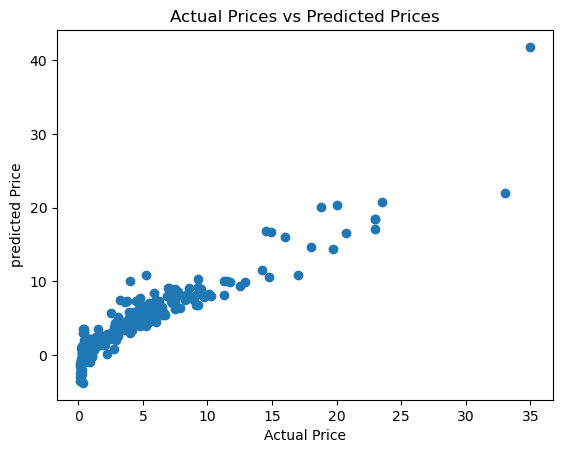

In [20]:
#Visualize the actual prices and predicted prices 
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show

In [21]:
#Prediction on Test data
test_data_prediction = lin_reg_model.predict(X_test)

In [22]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.836576671502587


<function matplotlib.pyplot.show(close=None, block=None)>

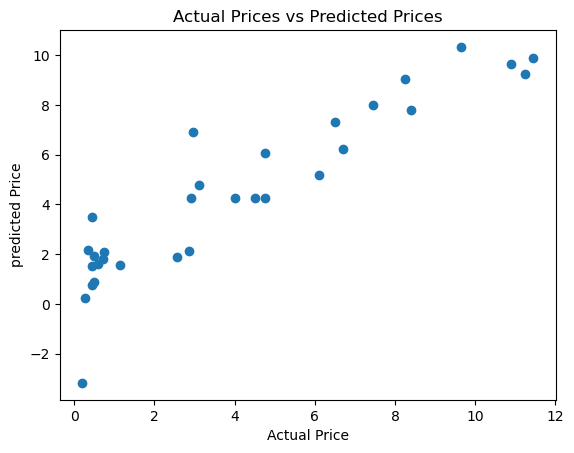

In [23]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show

In [24]:
# Lasso Regression 

import numpy as np
#   Creating a class for Lasso Regression
class Lasso_Regression():

    #   Initiating the hyperparameter
    def __init__(self, learning_rate = 0.01, no_of_iteration = 1000, lambda_parameter = 0.1):

        self.learning_rate = learning_rate
        self.no_of_iteration = no_of_iteration
        self.lambda_parameter = lambda_parameter

    #   fitting the dataset to the Lasso Regression 
    def fit(self, X, Y):

        #   m ----> number of Data points ----> number of rows
        #   n ----> number of Input features ----> number of columns
        self.m, self.n = X.shape

        self.w = np.zeros(self.n)
        self.b = 0 

        X = np.asarray(X)
        Y = np.asarray(Y)

        self.X = X
        self.Y = Y


        #   implementing the Gradient descent algorithm 
        for i in range(self.no_of_iteration):
            self.update_weights()

        return self    

        
    #   function for updating the weight & bias value
    def update_weights(self):

        #   linear equation of the model 
        Y_prediction = self.predict(self.X)

        #   gradients (dw, db)
        #   gradient for weight
        dw = np.zeros(self.n)

        for i in range(self.n):
            if self.w[i] > 0:
                dw[i] = (-(2*(self.X[:,i]).dot(self.Y - Y_prediction)) + self.lambda_parameter) / self.m
            else:
                dw[i] = (-(2*(self.X[:,i]).dot(self.Y - Y_prediction)) - self.lambda_parameter) / self.m

        #   gradient for bias 
        db = (-2 * np.sum(self.Y - Y_prediction))/ self.m 

        #   Updating weight and bias 
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db


    #   Predicting the target value
    def predict(self, X):

        return X.dot(self.w) + self.b


In [25]:
#Loading the lasso Regression model 
lass_reg_model = Lasso_Regression()

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lass_reg_model.fit(X_train_scaled, Y_train)

In [27]:
print(lass_reg_model.w)
print(lass_reg_model.b)

[ 1.20685146  3.90777258 -0.27211378  0.72648966 -0.47888241  0.51276263
 -0.22211652]
4.732148140184143


In [28]:
# Model Evaluation
#Prediction on Training data
training_data_prediction = lass_reg_model.predict(X_train_scaled)

In [29]:
# R squared Error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8799451327737478


<function matplotlib.pyplot.show(close=None, block=None)>

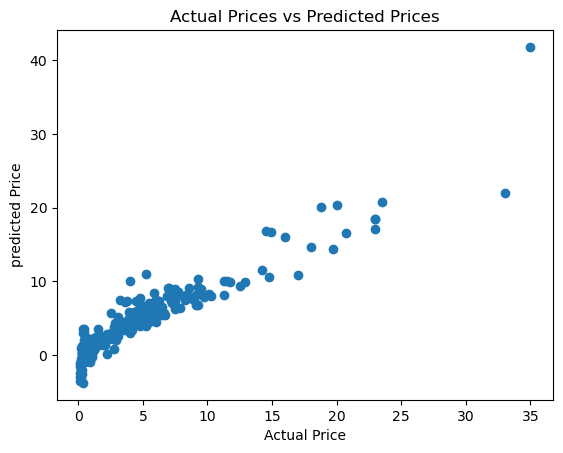

In [30]:
#Visualize the actual prices and predicted prices 
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show

In [31]:
#Prediction on Test data

X_test_scaled = scaler.transform(X_test)
test_data_prediction = lass_reg_model.predict(X_test_scaled)

In [32]:
# R squared Error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared Error : ", error_score)

R squared Error :  0.8365463053603587


<function matplotlib.pyplot.show(close=None, block=None)>

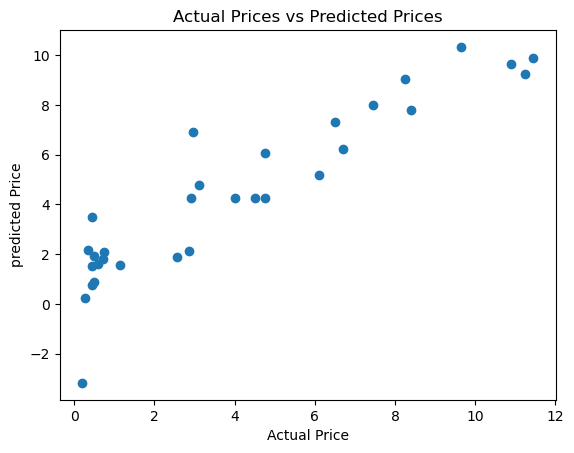

In [33]:
plt.scatter(Y_test, test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show

In [ ]:
#   1. Mean Absolute Error (MAE) and Mean Squared Error (MSE)

from sklearn import metrics
mae = metrics.mean_absolute_error(Y_test, test_data_prediction)
mse = metrics.mean_squared_error(Y_test, test_data_prediction)
rmse = mse ** 0.5

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 1.1516673729720364
MSE: 2.150529440592836
RMSE: 1.4664683564921666


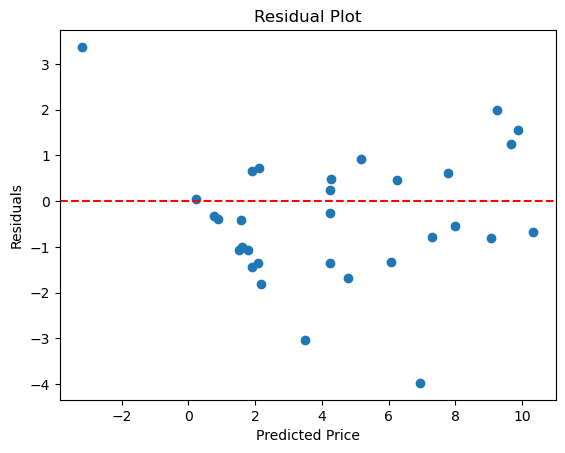

In [35]:
#   2. Residual plots

residuals = Y_test - test_data_prediction
plt.scatter(test_data_prediction, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [36]:
# Combine actual, predicted, and residuals into one table for inspection

results_df = pd.DataFrame({
    'Actual_Price': Y_test,
    'Predicted_Price': test_data_prediction,
    'Residual': Y_test.values - test_data_prediction
})

# Sort by the size of the mistake (biggest misses first, regardless of direction)
results_df['Abs_Residual'] = results_df['Residual'].abs()
results_df_sorted = results_df.sort_values('Abs_Residual', ascending=False)

print(results_df_sorted.head(5))

     Actual_Price  Predicted_Price  Residual  Abs_Residual
35           2.95         6.927621 -3.977621      3.977621
192          0.20        -3.174952  3.374952      3.374952
159          0.45         3.496993 -3.046993      3.046993
237         11.25         9.249510  2.000490      2.000490
178          0.35         2.172621 -1.822621      1.822621


In [37]:
car_dataset.loc[results_df_sorted.head(5).index]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
35,sx4,2011,2.95,7.74,49998,2,0,0,0
192,Hero Hunk,2007,0.20,0.75,49000,0,1,0,1
159,Honda Activa 4G,2017,0.45,0.51,4000,0,1,1,0
237,creta,2015,11.25,13.60,68000,1,0,0,0
178,TVS Jupyter,2014,0.35,0.52,19000,0,1,1,0


In [39]:
coefficients = pd.Series(lass_reg_model.w, index=X.columns)
print(coefficients)

Year             1.206851
Present_Price    3.907773
Kms_Driven      -0.272114
Fuel_Type        0.726490
Seller_Type     -0.478882
Transmission     0.512763
Owner           -0.222117
dtype: float64


In [ ]:
# Testing higher regularization strength (lambda_parameter) to see if it 
#   pushes weak features (Kms_Driven, Owner) toward zero

In [40]:
lass_reg_model_strong = Lasso_Regression(learning_rate=0.01, no_of_iteration=1000, lambda_parameter=1.0)
lass_reg_model_strong.fit(X_train_scaled, Y_train)

coefficients_strong = pd.Series(lass_reg_model_strong.w, index=X.columns)
print(coefficients_strong)

Year             1.206585
Present_Price    3.907271
Kms_Driven      -0.270054
Fuel_Type        0.725360
Seller_Type     -0.478013
Transmission     0.511018
Owner           -0.220712
dtype: float64


In [41]:
lass_reg_model_strong = Lasso_Regression(learning_rate=0.01, no_of_iteration=1000, lambda_parameter=100)
lass_reg_model_strong.fit(X_train_scaled, Y_train)

coefficients_strong = pd.Series(lass_reg_model_strong.w, index=X.columns)
print(coefficients_strong)

test_pred_strong = lass_reg_model_strong.predict(X_test_scaled)
print("R²:", metrics.r2_score(Y_test, test_pred_strong))

Year             1.177224
Present_Price    3.852099
Kms_Driven      -0.043497
Fuel_Type        0.601127
Seller_Type     -0.382351
Transmission     0.319070
Owner           -0.066252
dtype: float64
R²: 0.8576348723209097


In [43]:
lass_reg_model_strong = Lasso_Regression(learning_rate=0.01, no_of_iteration=1000, lambda_parameter=500)
lass_reg_model_strong.fit(X_train_scaled, Y_train)

coefficients_strong = pd.Series(lass_reg_model_strong.w, index=X.columns)
print(coefficients_strong)

test_pred_strong = lass_reg_model_strong.predict(X_test_scaled)
print("R²:", metrics.r2_score(Y_test, test_pred_strong))

Year             0.501207
Present_Price    3.545027
Kms_Driven      -0.004915
Fuel_Type        0.219176
Seller_Type     -0.018973
Transmission    -0.001075
Owner            0.003292
dtype: float64
R²: 0.8036467908835282


In [45]:
lass_reg_model_strong = Lasso_Regression(learning_rate=0.01, no_of_iteration=1000, lambda_parameter=250)
lass_reg_model_strong.fit(X_train_scaled, Y_train)

coefficients_strong = pd.Series(lass_reg_model_strong.w, index=X.columns)
print(coefficients_strong)

test_pred_strong = lass_reg_model_strong.predict(X_test_scaled)
print("R²:", metrics.r2_score(Y_test, test_pred_strong))

Year             0.944403
Present_Price    3.792288
Kms_Driven      -0.007360
Fuel_Type        0.452680
Seller_Type     -0.222468
Transmission     0.079075
Owner           -0.007584
dtype: float64
R²: 0.8521313110024936


In [47]:
lass_reg_model_strong = Lasso_Regression(learning_rate=0.01, no_of_iteration=10000, lambda_parameter=300)
lass_reg_model_strong.fit(X_train_scaled, Y_train)

coefficients_strong = pd.Series(lass_reg_model_strong.w, index=X.columns)
print(coefficients_strong)

test_pred_strong = lass_reg_model_strong.predict(X_test_scaled)
print("R²:", metrics.r2_score(Y_test, test_pred_strong))

Year             0.857254
Present_Price    3.775270
Kms_Driven      -0.007838
Fuel_Type        0.404164
Seller_Type     -0.166277
Transmission     0.001346
Owner           -0.015890
dtype: float64
R²: 0.8435344027643896
